# 準備 Training Data

# 1. 安裝與 import

In [1]:
!pip install -q datasets opencv-python-headless

import cv2
import numpy as np
from PIL import Image
from datasets import load_dataset
import os
from IPython.display import display
import json

# 2. 載入資料
人臉

載 500 筆

README.md:   0%|          | 0.00/450 [00:00<?, ?B/s]

收集到 500 張人臉圖片


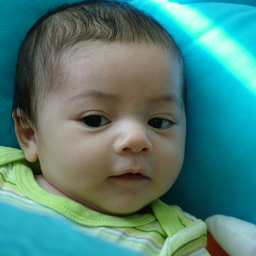

In [3]:
os.makedirs("training_data/conditioning_images", exist_ok=True)
os.makedirs("training_data/images", exist_ok=True)

# streaming=True 避免把整個資料集（5GB）全下載
ds_full = load_dataset("merkol/ffhq-256", split="train", streaming=True)

face_images = []
for sample in ds_full:
    face_images.append(sample["image"])
    if len(face_images) >= 500:
        break

print(f"收集到 {len(face_images)} 張人臉圖片")
display(face_images[0])

# 3. 生成 sketch 並存檔

使用以下測試後，發現 canny 在人臉的效果比 morphological gradient 好，所以改用 canny 。

In [ ]:
'''
from PIL import Image
import cv2, numpy as np
from IPython.display import display

# 載入一張已存的照片來測試
test_photo = Image.open("/content/drive/MyDrive/++DL/04_project_face/training_data/images/0000.png")

def sketch_morph(pil_image, threshold=15):
    img = np.array(pil_image.convert("RGB").resize((512, 512)))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = np.ones((3, 3), np.uint8)
    gradient = cv2.morphologyEx(gray, cv2.MORPH_GRADIENT, kernel)
    _, edges = cv2.threshold(gradient, threshold, 255, cv2.THRESH_BINARY)
    return Image.fromarray(cv2.cvtColor(cv2.bitwise_not(edges), cv2.COLOR_GRAY2RGB))

def sketch_canny(pil_image, low=30, high=100):
    img = np.array(pil_image.convert("RGB").resize((512, 512)))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, low, high)
    return Image.fromarray(cv2.cvtColor(cv2.bitwise_not(edges), cv2.COLOR_GRAY2RGB))

print("Original:")
display(test_photo)
print("Morph threshold=15:")
display(sketch_morph(test_photo, threshold=15))
print("Canny low=30, high=100:")
display(sketch_canny(test_photo, low=30, high=100))
'''

In [10]:
def photo_to_sketch(pil_image):
    img = np.array(pil_image.convert("RGB").resize((512, 512)))
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    # 先稍微模糊，減少皮膚紋理雜訊
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 30, 100)  # low=30, high=100
    edges_inv = cv2.bitwise_not(edges)
    sketch = cv2.cvtColor(edges_inv, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(sketch)

for i, photo in enumerate(face_images):
    photo_resized = photo.convert("RGB").resize((512, 512))
    sketch = photo_to_sketch(photo_resized)
    photo_resized.save(f"training_data/images/{i:04d}.png")
    sketch.save(f"training_data/conditioning_images/{i:04d}.png")
    if i % 20 == 0:
        print(f"Processed {i}/500")

print("存檔完成！")

Processed 0/500
Processed 20/500
Processed 40/500
Processed 60/500
Processed 80/500
Processed 100/500
Processed 120/500
Processed 140/500
Processed 160/500
Processed 180/500
Processed 200/500
Processed 220/500
Processed 240/500
Processed 260/500
Processed 280/500
Processed 300/500
Processed 320/500
Processed 340/500
Processed 360/500
Processed 380/500
Processed 400/500
Processed 420/500
Processed 440/500
Processed 460/500
Processed 480/500
存檔完成！


# 4. 確認一對 pair

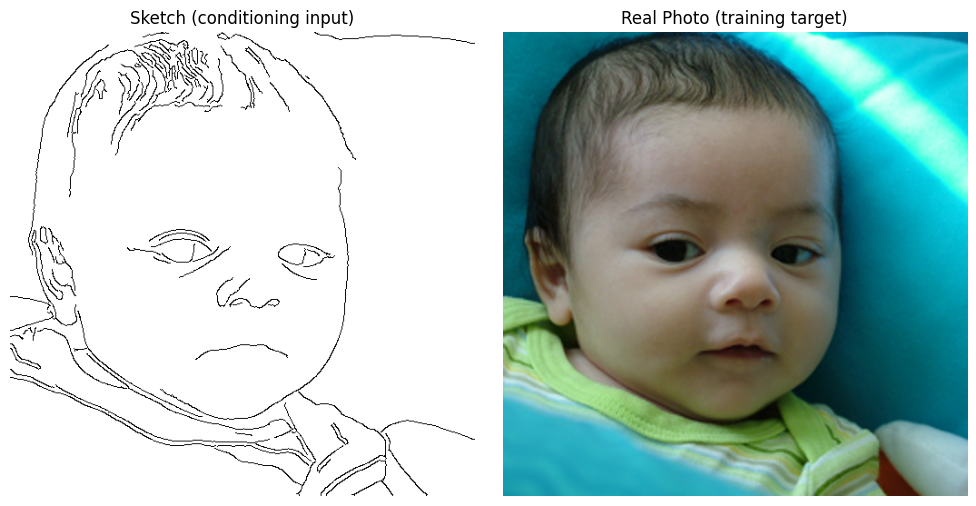

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(Image.open("training_data/conditioning_images/0000.png"))
axes[0].set_title("Sketch (conditioning input)")
axes[0].axis("off")
axes[1].imshow(Image.open("training_data/images/0000.png"))
axes[1].set_title("Real Photo (training target)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

# 5. 建立 metadata.jsonl

In [12]:
with open("training_data/train.jsonl", "w") as f:
    for i in range(len(face_images)):
        entry = {
            "image": f"images/{i:04d}.png",
            "conditioning_image": f"conditioning_images/{i:04d}.png",
            "text": "a person, photorealistic, high quality, detailed skin"
        }
        f.write(json.dumps(entry) + "\n")

print(f"metadata 建立完成，共 {len(face_images)} 筆")

# 確認格式正確
with open("training_data/train.jsonl") as f:
    print("第一行：", f.readline())

metadata 建立完成，共 500 筆
第一行： {"image": "images/0000.png", "conditioning_image": "conditioning_images/0000.png", "text": "a person, photorealistic, high quality, detailed skin"}



# 6. 把資料存到 google drive
記得改成自己的路徑

In [13]:
import shutil, os
from google.colab import drive
drive.mount('/content/drive')

# 如果 Drive 上舊的資料夾存在，先刪掉再複製
drive_path = "/content/drive/MyDrive/++DL/04_project_face/training_data"
if os.path.exists(drive_path):
    shutil.rmtree(drive_path)

shutil.copytree("training_data", drive_path)
print("500 筆備份完成！")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
500 筆備份完成！


In [ ]:
# 重新掛載 Drive，把資料複製回來
# 這裡也記得改成自己的路徑
'''
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree(
    "/content/drive/MyDrive/++DL/04_project_face/training_data",
    "training_data"
)
print("資料還原完成！")
'''